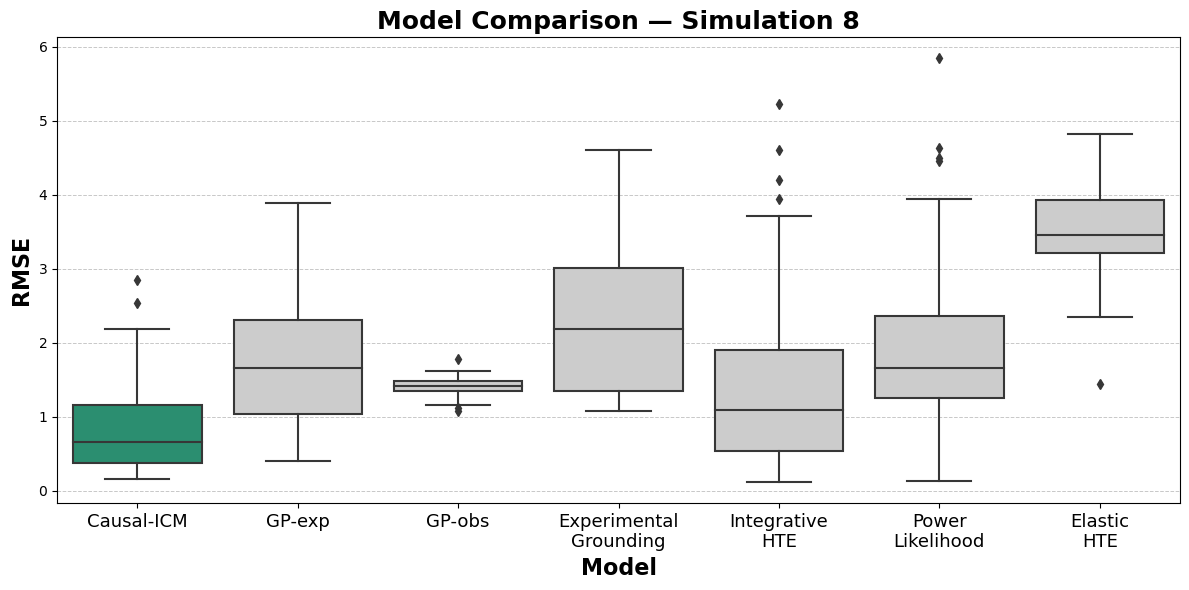

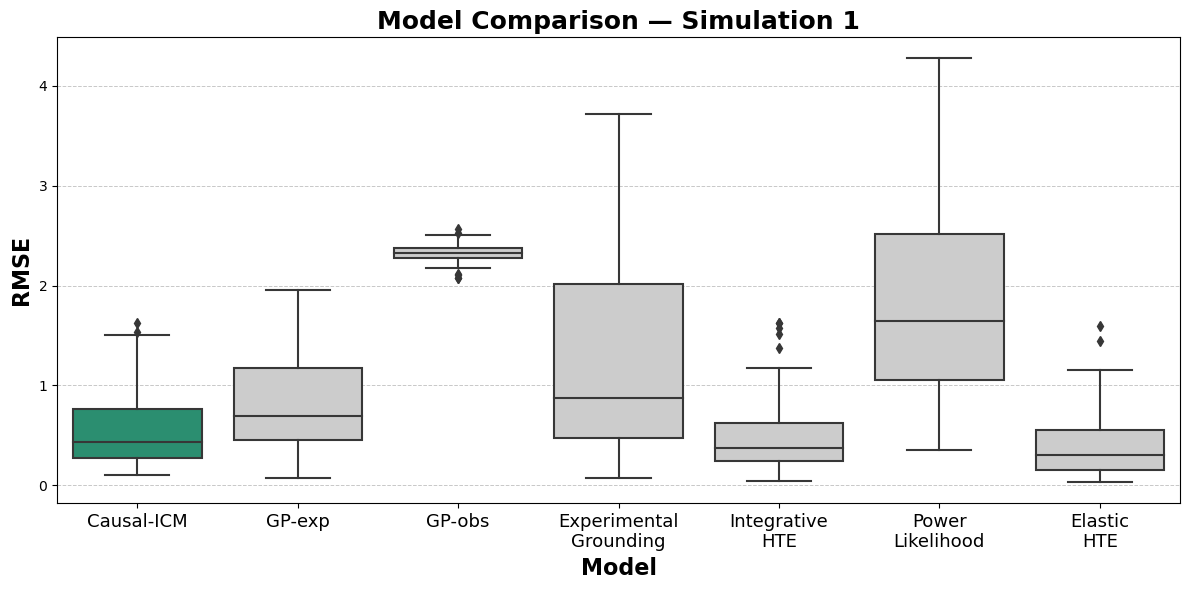

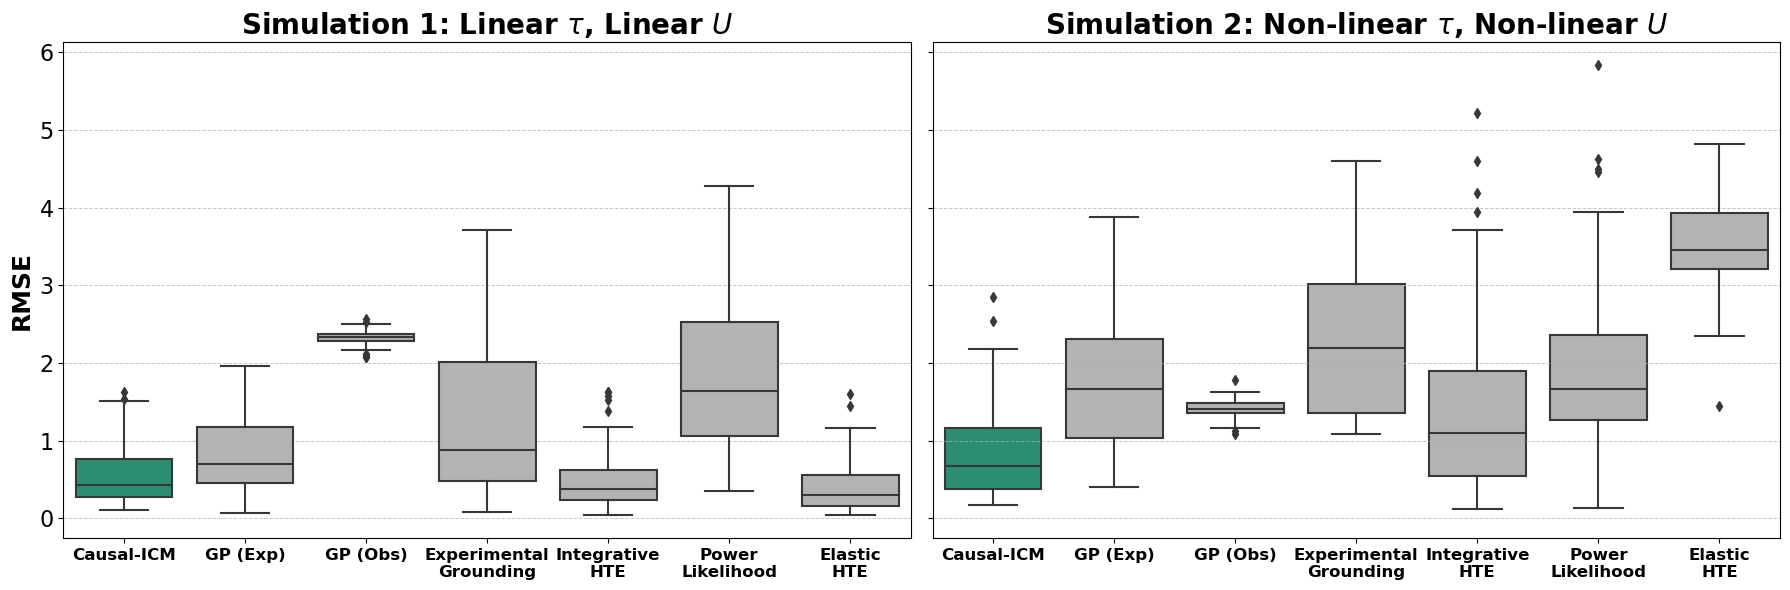

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import rpy2.robjects as ro
from rpy2.robjects import pandas2ri
pandas2ri.activate()

# -----------------------------------------------------
# Helper function: load simulation results
# -----------------------------------------------------

def load_simulation(sim_number, modelComp_path, integrative_path, powerLik_path, elastic_path):
    """Load a simulation's results and return a tidy df with RMSE values."""
    
    # CSV results
    modelComp = pd.read_csv(modelComp_path)
    integrative = pd.read_csv(integrative_path)

    # Power Likelihood RDS
    pl = ro.r['readRDS'](powerLik_path)
    pl_rmse = list(pl.rx2('rmse_list'))

    # Elastic RDS
    elastic_rmse = ro.r['readRDS'](elastic_path)

    # Build master dataframe
    df = pd.DataFrame({
        'ICM': modelComp['RMSE_ICM'].values,
        'naiveGP_exp': modelComp['RMSE_naiveGPexp'],
        'naiveGP_obs': modelComp['RMSE_naiveGPobs'],
        'expGrounding': modelComp['RMSE_KallusGP'],
        'integrativeHTE': integrative['RMSE'],
        'powerLik': pl_rmse,
        'elasticHTE': elastic_rmse
    })

    return df


# -----------------------------------------------------
# Helper function: plot one simulation
# -----------------------------------------------------

def plot_simulation(df_rmse, sim_number, ax=None):
    """Produces a boxplot of RMSE for one simulation."""
    
    new_labels = ['Causal-ICM', 'GP-exp', 'GP-obs', 'Experimental\nGrounding', 
                  'Integrative\nHTE', 'Power\nLikelihood', 'Elastic\nHTE']
    
    palette = {col: "#1b9e77" if col == 'ICM' else "#cccccc" for col in df_rmse.columns}
    
    df_melt = df_rmse.melt(var_name="Model", value_name="RMSE")

    created_new_fig = False
    if ax is None:
        fig, ax = plt.subplots(figsize=(12,6))
        created_new_fig = True

    sns.boxplot(data=df_melt, x='Model', y='RMSE', palette=palette, ax=ax)

    ax.set_xticklabels(new_labels, rotation=0, fontsize=13)
    ax.set_xlabel("Model", fontsize=16, fontweight='bold')
    ax.set_ylabel("RMSE", fontsize=16, fontweight='bold')
    ax.set_title(f"Model Comparison — Simulation {sim_number}", fontsize=18, fontweight='bold')

    ax.yaxis.grid(True, linestyle='--', linewidth=0.7, alpha=0.7)
    ax.set_axisbelow(True)

    if created_new_fig:
        plt.tight_layout()
        plt.show()

    return ax


# -----------------------------------------------------
# ------------ Load all simulations -------------------
# -----------------------------------------------------


# Simulation 8
df_rmse_sim8 = load_simulation(
    sim_number=8,
    modelComp_path="/Users/evangelosdimitriou/myGitRepo/multi-task-GPs-for-Treatment-Effect-Estimation-2/__pycache__/neurIPS/Simulation 8/sim8_modelComparison.csv",
    integrative_path="/Users/evangelosdimitriou/myGitRepo/multi-task-GPs-for-Treatment-Effect-Estimation-2/__pycache__/neurIPS/Simulation 8/results_ShuYang_quad.csv",
    powerLik_path="/Users/evangelosdimitriou/Documents/CLeaR/Xi Lin Many Data/cate_rmse_results.rds",
    elastic_path="/Users/evangelosdimitriou/Documents/CLeaR/ElasticIntegrative/sim8_rmse.rds"
)

# Simulation 1
df_rmse_sim1 = load_simulation(
    sim_number=1,
    modelComp_path="/Users/evangelosdimitriou/myGitRepo/multi-task-GPs-for-Treatment-Effect-Estimation-2/__pycache__/neurIPS/Simulation 1/sim1_modelComparison.csv",
    integrative_path="/Users/evangelosdimitriou/myGitRepo/multi-task-GPs-for-Treatment-Effect-Estimation-2/__pycache__/neurIPS/Simulation 1/results_ShuYang.csv",
    powerLik_path="/Users/evangelosdimitriou/Documents/CLeaR/Xi Lin Many Data/cate_rmse_results_sim1.rds",
    elastic_path="/Users/evangelosdimitriou/Documents/CLeaR/ElasticIntegrative/sim1_rmse.rds"
)



# -----------------------------------------------------
# ------------ Plot each simulation separately ---------
# -----------------------------------------------------

plot_simulation(df_rmse_sim8, sim_number=8)
plot_simulation(df_rmse_sim1, sim_number=1)


# -----------------------------------------------------
# Create melted dfs & palette for combined plot
# -----------------------------------------------------
df_melt_sim1 = df_rmse_sim1.melt(var_name="Model", value_name="RMSE")
df_melt_sim8 = df_rmse_sim8.melt(var_name="Model", value_name="RMSE")

palette = {col: "#1b9e77" if col == 'ICM' else "#b3b3b3" for col in df_rmse_sim1.columns}

# -----------------------------------------------------
# ------------ Combined subfigure plot -----------------
# -----------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=True)

# Left subplot: Simulation 1
sns.boxplot(data=df_melt_sim1, x='Model', y='RMSE', palette=palette, ax=axes[0])
axes[0].set_title("Simulation 1: Linear $\\tau$, Linear $U$", fontsize=20, fontweight='bold')
axes[0].set_xlabel("")
axes[0].set_ylabel("RMSE", fontsize=18, fontweight='bold')

axes[0].tick_params(axis='y', labelsize=16)

axes[0].set_xticklabels(["Causal-ICM", "GP (Exp)", "GP (Obs)", "Experimental\nGrounding", "Integrative\nHTE", "Power\nLikelihood", "Elastic\nHTE"],
                        rotation=0, size = 12, fontweight = "bold")

axes[0].yaxis.grid(True, linestyle='--', linewidth=0.7, alpha=0.7)
axes[0].set_axisbelow(True)

# Right subplot: Simulation 8
sns.boxplot(data=df_melt_sim8, x='Model', y='RMSE', palette=palette, ax=axes[1])
axes[1].set_title("Simulation 2: Non-linear $\\tau$, Non-linear $U$", fontsize=20, fontweight='bold')
axes[1].set_xlabel("")
axes[1].set_ylabel("")

axes[1].set_xticklabels(["Causal-ICM", "GP (Exp)", "GP (Obs)", "Experimental\nGrounding", "Integrative\nHTE", "Power\nLikelihood", "Elastic\nHTE"],
                        rotation=0, size = 12, fontweight = "bold")
axes[1].yaxis.grid(True, linestyle='--', linewidth=0.7, alpha=0.7)
axes[0].set_axisbelow(True)

plt.tight_layout()
plt.show()




In [15]:
def load_simulation(sim_number, modelComp_path, integrative_path, powerLik_path, elastic_path):
    """Load a simulation's results and return a tidy df with RMSE values."""
    
    # CSV results
    modelComp = pd.read_csv(modelComp_path)
    integrative = pd.read_csv(integrative_path)

    # Power Likelihood RDS
    pl = ro.r['readRDS'](powerLik_path)
    pl_rmse = list(pl.rx2('rmse_list'))

    # Elastic RDS
    elastic_rmse = ro.r['readRDS'](elastic_path)

    # Build master dataframe
    df = pd.DataFrame({
        'ICM': modelComp['RMSE_ICM'].values,
        'naiveGP_exp': modelComp['RMSE_naiveGPexp'],
        'naiveGP_obs': modelComp['RMSE_naiveGPobs'],
        'expGrounding': modelComp['RMSE_KallusGP'],
        'integrativeHTE': integrative['RMSE'],
        'powerLik': pl_rmse,
        'elasticHTE': elastic_rmse
    })

    return df


# Simulation 8
df_rmse_sim8 = load_simulation(
    sim_number=8,
    modelComp_path="/Users/evangelosdimitriou/myGitRepo/multi-task-GPs-for-Treatment-Effect-Estimation-2/__pycache__/neurIPS/Simulation 8/sim8_modelComparison.csv",
    integrative_path="/Users/evangelosdimitriou/myGitRepo/multi-task-GPs-for-Treatment-Effect-Estimation-2/__pycache__/neurIPS/Simulation 8/results_ShuYang_quad.csv",
    powerLik_path="/Users/evangelosdimitriou/Documents/CLeaR/Xi Lin Many Data/cate_rmse_results.rds",
    elastic_path="/Users/evangelosdimitriou/Documents/CLeaR/ElasticIntegrative/sim8_rmse.rds"
)

# Simulation 1
df_rmse_sim1 = load_simulation(
    sim_number=1,
    modelComp_path="/Users/evangelosdimitriou/myGitRepo/multi-task-GPs-for-Treatment-Effect-Estimation-2/__pycache__/neurIPS/Simulation 1/sim1_modelComparison.csv",
    integrative_path="/Users/evangelosdimitriou/myGitRepo/multi-task-GPs-for-Treatment-Effect-Estimation-2/__pycache__/neurIPS/Simulation 1/results_ShuYang.csv",
    powerLik_path="/Users/evangelosdimitriou/Documents/CLeaR/Xi Lin Many Data/cate_rmse_results_sim1.rds",
    elastic_path="/Users/evangelosdimitriou/Documents/CLeaR/ElasticIntegrative/sim1_rmse.rds"
)

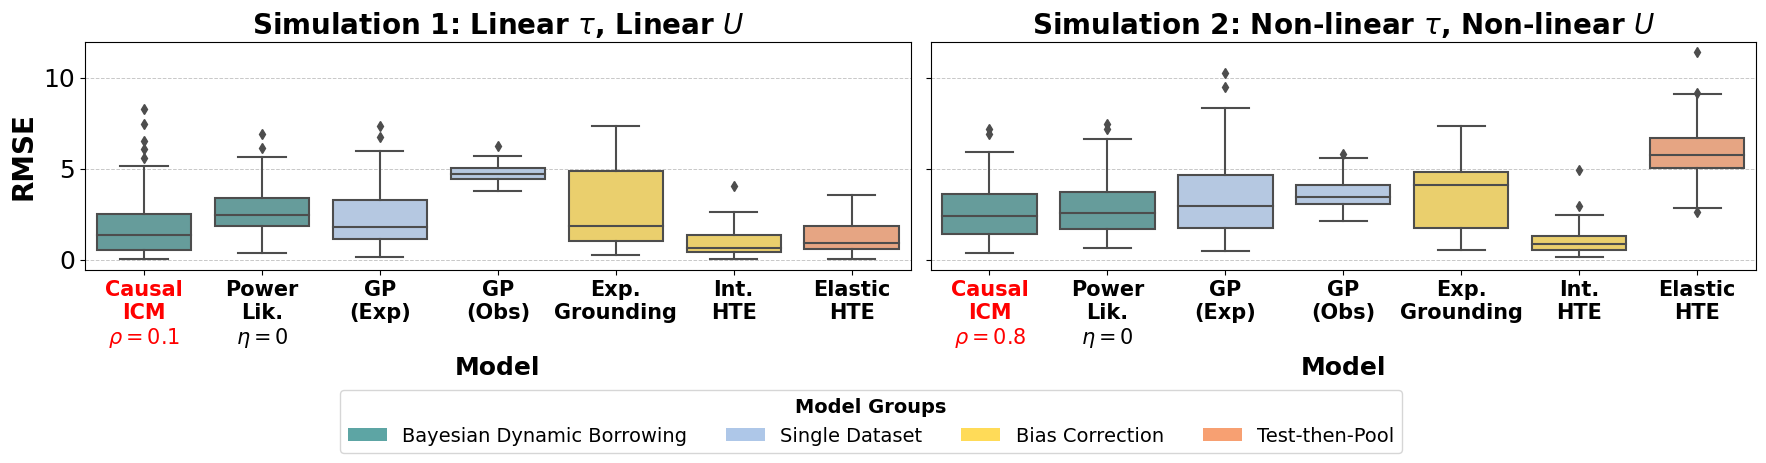

In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------------------------------
# Global order + colours + labels
# -----------------------------------------------------
desired_order = [
    "ICM", "powerLik",
    "naiveGP_exp", "naiveGP_obs",
    "expGrounding", "integrativeHTE",
    "elasticHTE"
]

label_map_sim1 = {
    "ICM": "Causal\nICM\n$\\rho=0.1$",
    "powerLik": "Power\nLik.\n$\\eta=0$",
    "naiveGP_exp": "GP\n(Exp)",
    "naiveGP_obs": "GP\n(Obs)",
    "expGrounding": "Exp.\nGrounding",
    "integrativeHTE": "Int.\nHTE",
    "elasticHTE": "Elastic\nHTE"
}

label_map_sim8 = {
    "ICM": "Causal\nICM\n$\\rho=0.8$",
    "powerLik": "Power\nLik.\n$\\eta=0$",
    "naiveGP_exp": "GP\n(Exp)",
    "naiveGP_obs": "GP\n(Obs)",
    "expGrounding": "Exp.\nGrounding",
    "integrativeHTE": "Int.\nHTE",
    "elasticHTE": "Elastic\nHTE"
}

color_map = {
    "ICM": "#5DA5A4", "powerLik": "#5DA5A4",                 # Bayesian Dynamic Borrowing
    "naiveGP_exp": "#AEC7E8", "naiveGP_obs": "#AEC7E8",     # Single Dataset
    "expGrounding": "#FFDB58", "integrativeHTE": "#FFDB58", # Bias Correction
    "elasticHTE": "#F7A072"                                 # Test-then-Poll
}

# -----------------------------------------------------
# Plotting function (self-contained)
# -----------------------------------------------------
def plot_simulation(df_rmse, sim_number, ax=None):

    # Melt
    df_melt = df_rmse.melt(var_name="Model", value_name="RMSE")

    # reorder categories
    df_melt["Model"] = pd.Categorical(
        df_melt["Model"], categories=desired_order, ordered=True
    )

    # Create axis if needed
    created_new_fig = False
    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 6))
        created_new_fig = True

    # Boxplot
    sns.boxplot(data=df_melt, x="Model", y="RMSE", palette=color_map, ax=ax)

    # Labels
    ax.set_xticklabels([label_map_sim1[m] for m in desired_order], rotation=0, fontsize=13)
    ax.set_xlabel("")
    ax.set_ylabel("RMSE", fontsize=16, fontweight="bold")
    ax.set_title(f"Model Comparison — Simulation {sim_number}", fontsize=18, fontweight="bold")

    # Grid
    ax.yaxis.grid(True, linestyle="--", linewidth=0.7, alpha=0.7)
    ax.set_axisbelow(True)

    if created_new_fig:
        plt.tight_layout()
        plt.show()

    return ax

# -----------------------------------------------------
# Dummy data so the code runs independently
# Replace these with your real simulation outputs
# -----------------------------------------------------
np.random.seed(1)

df_rmse_sim1 = pd.DataFrame({
    "ICM": df_rmse_sim1["ICM"],
    "powerLik": df_rmse_sim1["powerLik"],
    "naiveGP_exp": df_rmse_sim1["naiveGP_exp"],
    "naiveGP_obs": df_rmse_sim1["naiveGP_obs"],
    "expGrounding": df_rmse_sim1["expGrounding"],
    "integrativeHTE": df_rmse_sim1["integrativeHTE"],
    "elasticHTE": df_rmse_sim1["elasticHTE"]
})

df_rmse_sim8 = pd.DataFrame({
    "ICM": df_rmse_sim8["ICM"],
    "powerLik": df_rmse_sim8["powerLik"],
    "naiveGP_exp": df_rmse_sim8["naiveGP_exp"],
    "naiveGP_obs": df_rmse_sim8["naiveGP_obs"],
    "expGrounding": df_rmse_sim8["expGrounding"],
    "integrativeHTE": df_rmse_sim8["integrativeHTE"],
    "elasticHTE": df_rmse_sim8["elasticHTE"]
})

# -----------------------------------------------------
# Combined plot example (also self-contained)
# -----------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(18, 4), sharey=True)

# Simulation 1
df_melt_sim1 = df_rmse_sim1.melt(var_name="Model", value_name="RMSE")
df_melt_sim1["Model"] = pd.Categorical(df_melt_sim1["Model"], categories=desired_order, ordered=True)

sns.boxplot(data=df_melt_sim1, x="Model", y="RMSE",
            palette=color_map, ax=axes[0])
axes[0].set_title("Simulation 1: Linear $\\tau$, Linear $U$", fontsize=20, fontweight="bold")
axes[0].set_xlabel("Model", fontsize=18, fontweight="bold")
axes[0].set_ylabel("RMSE", fontsize=20, fontweight="bold")

# Set tick labels and make "Causal-ICM" red
axes[0].set_xticklabels([label_map_sim1[m] for m in desired_order], rotation=0, fontsize=15, fontweight="bold")
ticks = axes[0].get_xticklabels()
ticks[0].set_color("red")
ticks[0].set_fontweight("extra bold")  # optional



# Simulation 8
df_melt_sim8 = df_rmse_sim8.melt(var_name="Model", value_name="RMSE")
df_melt_sim8["Model"] = pd.Categorical(df_melt_sim8["Model"], categories=desired_order, ordered=True)

sns.boxplot(data=df_melt_sim8, x="Model", y="RMSE",
            palette=color_map, ax=axes[1])
axes[1].set_title("Simulation 2: Non-linear $\\tau$, Non-linear $U$", fontsize=20, fontweight="bold")
axes[1].set_ylabel("")
axes[1].set_xlabel("Model", fontsize=18, fontweight="bold")

# Set tick labels and make "Causal-ICM" red
axes[1].set_xticklabels([label_map_sim8[m] for m in desired_order], rotation=0, fontsize=15, fontweight="bold")
ticks = axes[1].get_xticklabels()
ticks[0].set_color("red")
ticks[0].set_fontweight("extra bold")  # optional

for ax in axes:
    ax.tick_params(axis='y', labelsize=18)  # increase y-tick font size
    ax.yaxis.grid(True, linestyle="--", linewidth=0.7, alpha=0.7)
    ax.set_axisbelow(True)


from matplotlib.patches import Patch

legend_patches = [
    Patch(facecolor="#5DA5A4", label="Bayesian Dynamic Borrowing"),
    Patch(facecolor="#AEC7E8", label="Single Dataset"),
    Patch(facecolor="#FFDB58", label="Bias Correction"),
    Patch(facecolor="#F7A072", label="Test-then-Pool")
]

leg = fig.legend(
    handles=legend_patches,
    title="Model Groups",
    fontsize=14,
    loc="lower center",       # put legend at the bottom
    ncol=4,                   # make it horizontal with 4 columns
    bbox_to_anchor=(0.5, -0.17),   # center it & move slightly below the plot
)

# Make the legend title bold
leg.get_title().set_fontweight('bold')
leg.get_title().set_fontsize(14)  # optional: increase title size


plt.tight_layout()
plt.show()


# Coverage

In [17]:
import sys
sys.path.append("/Users/evangelosdimitriou/myGitRepo/multi-task-GPs-for-Treatment-Effect-Estimation-2/__pycache__/")
print(sys.path)

import pandas as pd
sim1_coverage = pd.read_csv('/Users/evangelosdimitriou/myGitRepo/multi-task-GPs-for-Treatment-Effect-Estimation-2/__pycache__/neurIPS/Simulation 1/sim1_coverage.csv')
sim1_length = pd.read_csv('/Users/evangelosdimitriou/myGitRepo/multi-task-GPs-for-Treatment-Effect-Estimation-2/__pycache__/neurIPS/Simulation 1/sim1_length.csv')
sim8_coverage = pd.read_csv('/Users/evangelosdimitriou/myGitRepo/multi-task-GPs-for-Treatment-Effect-Estimation-2/__pycache__/neurIPS/Simulation 8/sim8_coverage.csv')
sim8_length = pd.read_csv('/Users/evangelosdimitriou/myGitRepo/multi-task-GPs-for-Treatment-Effect-Estimation-2/__pycache__/neurIPS/Simulation 8/sim8_length.csv')

['/Users/evangelosdimitriou/myGitRepo/multi-task-GPs-for-Treatment-Effect-Estimation-2/__pycache__/neurIPS/CLeaR', '/Users/evangelosdimitriou/anaconda3/lib/python310.zip', '/Users/evangelosdimitriou/anaconda3/lib/python3.10', '/Users/evangelosdimitriou/anaconda3/lib/python3.10/lib-dynload', '', '/Users/evangelosdimitriou/anaconda3/lib/python3.10/site-packages', '/Users/evangelosdimitriou/anaconda3/lib/python3.10/site-packages/PyQt5_sip-12.11.0-py3.10-macosx-10.9-x86_64.egg', '/Users/evangelosdimitriou/anaconda3/lib/python3.10/site-packages/aeosa', '/Users/evangelosdimitriou/anaconda3/lib/python3.10/site-packages/mpmath-1.2.1-py3.10.egg', '/Users/evangelosdimitriou/myGitRepo/multi-task-GPs-for-Treatment-Effect-Estimation-2/__pycache__/', '/Users/evangelosdimitriou/myGitRepo/multi-task-GPs-for-Treatment-Effect-Estimation-2/__pycache__/']


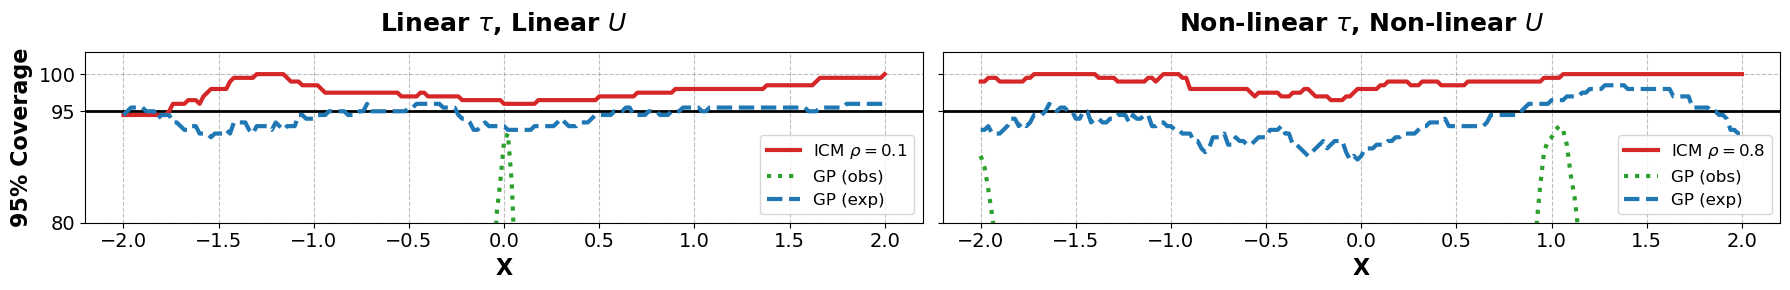

In [18]:
import matplotlib.pyplot as plt
import numpy as np

# ------------------------------
# Colors and styles
# ------------------------------
colors = {
    'ICM': '#d62728',   # red
    'TGP_obs': '#2ca02c',    # green
    'TGP_exp': '#1f77b4'      # blue
}
lw = 3  # line width

# ------------------------------
# Set up figure
# ------------------------------
fig, axes = plt.subplots(1, 2, figsize=(18, 3), sharey=True)

# Y ticks
y_ticks = list(range(0, 101, 20))
if 95 not in y_ticks:
    y_ticks.append(95)
y_ticks = sorted(y_ticks)

# ------------------------------
# Plot 1: Linear tau, Linear eta
# ------------------------------
axes[0].axhline(y=95, color='black', linestyle='-', linewidth=2)

axes[0].plot(sim1_coverage['test_data'], 100*sim1_coverage['coverageProbICM95'],
             color=colors['ICM'], linestyle='solid', linewidth=lw, label='ICM $\\rho=0.1$')
axes[0].plot(sim1_coverage['test_data'], 100*sim1_coverage['coverageProbGPobs95'],
             color=colors['TGP_obs'], linestyle='dotted', linewidth=lw, label='GP (obs)')
axes[0].plot(sim1_coverage['test_data'], 100*sim1_coverage['coverageProbGPexp95'],
             color=colors['TGP_exp'], linestyle='dashed', linewidth=lw, label='GP (exp)')


# Labels, ticks, grid
axes[0].set_xlabel('X', fontsize=16, fontweight='bold')
axes[0].set_ylabel('95% Coverage', fontsize=16, fontweight='bold')
axes[0].set_title("Linear $\\tau$, Linear $U$", fontsize=18, pad=15, fontweight='bold')
axes[0].tick_params(axis='both', labelsize=14)
axes[0].set_yticks(y_ticks)
axes[0].grid(True, linestyle='--', color='gray', alpha=0.5)
axes[0].set_ylim(80, 100)

# Legend for subplot 1
axes[0].legend(fontsize=12, loc='lower right')

# ------------------------------
# Plot 2: Non-linear tau, Non-linear eta
# ------------------------------
# Add thin black line at 95
axes[1].axhline(y=95, color='black', linestyle='-', linewidth=2)

axes[1].plot(sim8_coverage['test_data'], 100*sim8_coverage['coverageProbICM95'],
             color=colors['ICM'], linestyle='solid', linewidth=lw, label='ICM $\\rho=0.8$')
axes[1].plot(sim8_coverage['test_data'], 100*sim8_coverage['coverageProbGPobs95'],
             color=colors['TGP_obs'], linestyle='dotted', linewidth=lw, label='GP (obs)')
axes[1].plot(sim8_coverage['test_data'], 100*sim8_coverage['coverageProbGPexp95'],
             color=colors['TGP_exp'], linestyle='dashed', linewidth=lw, label='GP (exp)')



# Labels, ticks, grid
axes[1].set_xlabel('X', fontsize=16, fontweight='bold')
axes[1].tick_params(axis='both', labelsize=14)
axes[1].tick_params(labelleft=False)
axes[1].set_title("Non-linear $\\tau$, Non-linear $U$", fontsize=18, pad=15, fontweight='bold')
axes[1].set_yticks(y_ticks)
axes[1].grid(True, linestyle='--', color='gray', alpha=0.5)
axes[1].set_ylim(80, 103)

# Legend for subplot 2
axes[1].legend(fontsize=12, loc='lower right')

plt.tight_layout()
plt.show()


# Multivariate simulation setting

## Simulation 1: linear CATE, linear confounding

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import rpy2.robjects as ro
from rpy2.robjects import pandas2ri
pandas2ri.activate()

def load_simulation(sim_number, modelComp_path, integrative_path, powerLik_path, elastic_path):
    """Load a simulation's results and return a tidy df with RMSE values."""
    
    # CSV results
    modelComp = pd.read_csv(modelComp_path)
    integrative = pd.read_csv(integrative_path)

    # Power Likelihood RDS
    pl = ro.r['readRDS'](powerLik_path)
    pl_rmse = list(pl.rx2('rmse_list'))

    # Elastic RDS
    elastic_rmse = ro.r['readRDS'](elastic_path)

    # Build master dataframe
    df = pd.DataFrame({
        'ICM': modelComp['RMSE_ICM'].values,
        'naiveGP_exp': modelComp['RMSE_naiveGPexp'],
        'naiveGP_obs': modelComp['RMSE_naiveGPobs'],
        'expGrounding': modelComp['RMSE_KallusGP'],
        'integrativeHTE': integrative['RMSE'],
        'powerLik': pl_rmse,
        'elasticHTE': elastic_rmse
    })

    return df


# Simulation 1
df_rmse_sim1 = load_simulation(
    sim_number=1,
    modelComp_path="/Users/evangelosdimitriou/myGitRepo/multi-task-GPs-for-Treatment-Effect-Estimation-2/__pycache__/neurIPS/multivariate/Simulation 1/sim1_modelComparison.csv",
    integrative_path="/Users/evangelosdimitriou/myGitRepo/multi-task-GPs-for-Treatment-Effect-Estimation-2/__pycache__/neurIPS/multivariate/Simulation 1/results_ShuYang.csv",
    powerLik_path="/Users/evangelosdimitriou/Documents/CLeaR/Xi Lin Many Data/cate_rmse_results_mult_sim1.rds",
    elastic_path="/Users/evangelosdimitriou/Documents/CLeaR/ElasticIntegrative/mult_sim1_rmse.rds"
)

# Simulation 4
df_rmse_sim4 = load_simulation(
    sim_number=1,
    modelComp_path="/Users/evangelosdimitriou/myGitRepo/multi-task-GPs-for-Treatment-Effect-Estimation-2/__pycache__/neurIPS/multivariate/Simulation 4/sim4_modelComparison.csv",
    integrative_path="/Users/evangelosdimitriou/myGitRepo/multi-task-GPs-for-Treatment-Effect-Estimation-2/__pycache__/neurIPS/multivariate/Simulation 4/results_ShuYang.csv",
    powerLik_path="/Users/evangelosdimitriou/Documents/CLeaR/Xi Lin Many Data/cate_rmse_results_mult_sim4.rds",
    elastic_path="/Users/evangelosdimitriou/Documents/CLeaR/ElasticIntegrative/mult_sim4_rmse.rds"
)

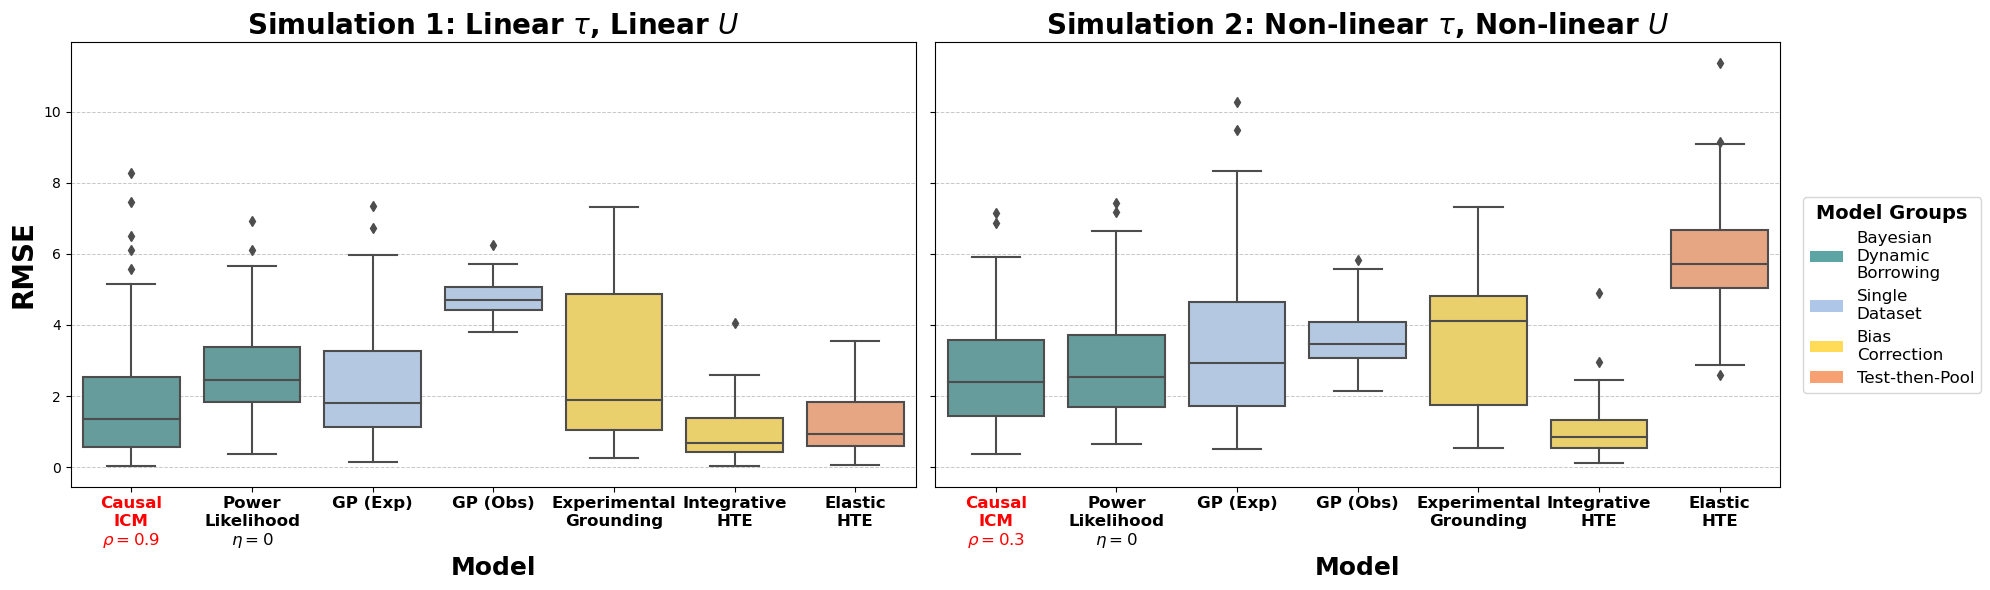

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------------------------------
# Global order + colours + labels
# -----------------------------------------------------
desired_order = [
    "ICM", "powerLik",
    "naiveGP_exp", "naiveGP_obs",
    "expGrounding", "integrativeHTE",
    "elasticHTE"
]

label_map_sim1 = {
    "ICM": "Causal\nICM\n$\\rho=0.9$",
    "powerLik": "Power\nLikelihood\n$\\eta=0$",
    "naiveGP_exp": "GP (Exp)",
    "naiveGP_obs": "GP (Obs)",
    "expGrounding": "Experimental\nGrounding",
    "integrativeHTE": "Integrative\nHTE",
    "elasticHTE": "Elastic\nHTE"
}

label_map_sim8 = {
    "ICM": "Causal\nICM\n$\\rho=0.3$",
    "powerLik": "Power\nLikelihood\n$\\eta=0$",
    "naiveGP_exp": "GP (Exp)",
    "naiveGP_obs": "GP (Obs)",
    "expGrounding": "Experimental\nGrounding",
    "integrativeHTE": "Integrative\nHTE",
    "elasticHTE": "Elastic\nHTE"
}

color_map = {
    "ICM": "#5DA5A4", "powerLik": "#5DA5A4",                 # Bayesian Dynamic Borrowing
    "naiveGP_exp": "#AEC7E8", "naiveGP_obs": "#AEC7E8",     # Single Dataset
    "expGrounding": "#FFDB58", "integrativeHTE": "#FFDB58", # Bias Correction
    "elasticHTE": "#F7A072"                                 # Test-then-Poll
}

# -----------------------------------------------------
# Plotting function (self-contained)
# -----------------------------------------------------
def plot_simulation(df_rmse, sim_number, ax=None):

    # Melt
    df_melt = df_rmse.melt(var_name="Model", value_name="RMSE")

    # reorder categories
    df_melt["Model"] = pd.Categorical(
        df_melt["Model"], categories=desired_order, ordered=True
    )

    # Create axis if needed
    created_new_fig = False
    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 6))
        created_new_fig = True

    # Boxplot
    sns.boxplot(data=df_melt, x="Model", y="RMSE", palette=color_map, ax=ax)

    # Labels
    ax.set_xticklabels([label_map_sim1[m] for m in desired_order], rotation=0, fontsize=13)
    ax.set_xlabel("")
    ax.set_ylabel("RMSE", fontsize=16, fontweight="bold")
    ax.set_title(f"Model Comparison — Simulation {sim_number}", fontsize=18, fontweight="bold")

    # Grid
    ax.yaxis.grid(True, linestyle="--", linewidth=0.7, alpha=0.7)
    ax.set_axisbelow(True)

    if created_new_fig:
        plt.tight_layout()
        plt.show()

    return ax

# -----------------------------------------------------
# Dummy data so the code runs independently
# Replace these with your real simulation outputs
# -----------------------------------------------------
np.random.seed(1)

df_rmse_sim1 = pd.DataFrame({
    "ICM": df_rmse_sim1["ICM"],
    "powerLik": df_rmse_sim1["powerLik"],
    "naiveGP_exp": df_rmse_sim1["naiveGP_exp"],
    "naiveGP_obs": df_rmse_sim1["naiveGP_obs"],
    "expGrounding": df_rmse_sim1["expGrounding"],
    "integrativeHTE": df_rmse_sim1["integrativeHTE"],
    "elasticHTE": df_rmse_sim1["elasticHTE"]
})

df_rmse_sim8 = pd.DataFrame({
    "ICM": df_rmse_sim4["ICM"],
    "powerLik": df_rmse_sim4["powerLik"],
    "naiveGP_exp": df_rmse_sim4["naiveGP_exp"],
    "naiveGP_obs": df_rmse_sim4["naiveGP_obs"],
    "expGrounding": df_rmse_sim4["expGrounding"],
    "integrativeHTE": df_rmse_sim4["integrativeHTE"],
    "elasticHTE": df_rmse_sim4["elasticHTE"]
})

# -----------------------------------------------------
# Combined plot example (also self-contained)
# -----------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=True)

# Simulation 1
df_melt_sim1 = df_rmse_sim1.melt(var_name="Model", value_name="RMSE")
df_melt_sim1["Model"] = pd.Categorical(df_melt_sim1["Model"], categories=desired_order, ordered=True)

sns.boxplot(data=df_melt_sim1, x="Model", y="RMSE",
            palette=color_map, ax=axes[0])
axes[0].set_title("Simulation 1: Linear $\\tau$, Linear $U$", fontsize=20, fontweight="bold")
axes[0].set_xlabel("Model", fontsize=18, fontweight="bold")
axes[0].set_ylabel("RMSE", fontsize=20, fontweight="bold")

# Set tick labels and make "Causal-ICM" red
axes[0].set_xticklabels([label_map_sim1[m] for m in desired_order], rotation=0, fontsize=12, fontweight="bold")
ticks = axes[0].get_xticklabels()
ticks[0].set_color("red")
ticks[0].set_fontweight("extra bold")  # optional



# Simulation 8
df_melt_sim8 = df_rmse_sim8.melt(var_name="Model", value_name="RMSE")
df_melt_sim8["Model"] = pd.Categorical(df_melt_sim8["Model"], categories=desired_order, ordered=True)

sns.boxplot(data=df_melt_sim8, x="Model", y="RMSE",
            palette=color_map, ax=axes[1])
axes[1].set_title("Simulation 2: Non-linear $\\tau$, Non-linear $U$", fontsize=20, fontweight="bold")
axes[1].set_ylabel("")
axes[1].set_xlabel("Model", fontsize=18, fontweight="bold")

# Set tick labels and make "Causal-ICM" red
axes[1].set_xticklabels([label_map_sim8[m] for m in desired_order], rotation=0, fontsize=12, fontweight="bold")
ticks = axes[1].get_xticklabels()
ticks[0].set_color("red")
ticks[0].set_fontweight("extra bold")  # optional

for ax in axes:
    ax.yaxis.grid(True, linestyle="--", linewidth=0.7, alpha=0.7)
    ax.set_axisbelow(True)


from matplotlib.patches import Patch

legend_patches = [
    Patch(facecolor="#5DA5A4", label="Bayesian\nDynamic\nBorrowing"),
    Patch(facecolor="#AEC7E8", label="Single\nDataset"),
    Patch(facecolor="#FFDB58", label="Bias\nCorrection"),
    Patch(facecolor="#F7A072", label="Test-then-Pool")
]

# Create the figure-level legend
leg = fig.legend(
    handles=legend_patches,
    title="Model Groups",
    fontsize=12,
    loc="center left",
    bbox_to_anchor=(1.0, 0.5)
)

# Make the legend title bold
leg.get_title().set_fontweight('bold')
leg.get_title().set_fontsize(14)  # optional: increase title size


plt.tight_layout()
plt.show()


# Extrapolation and model fit plot

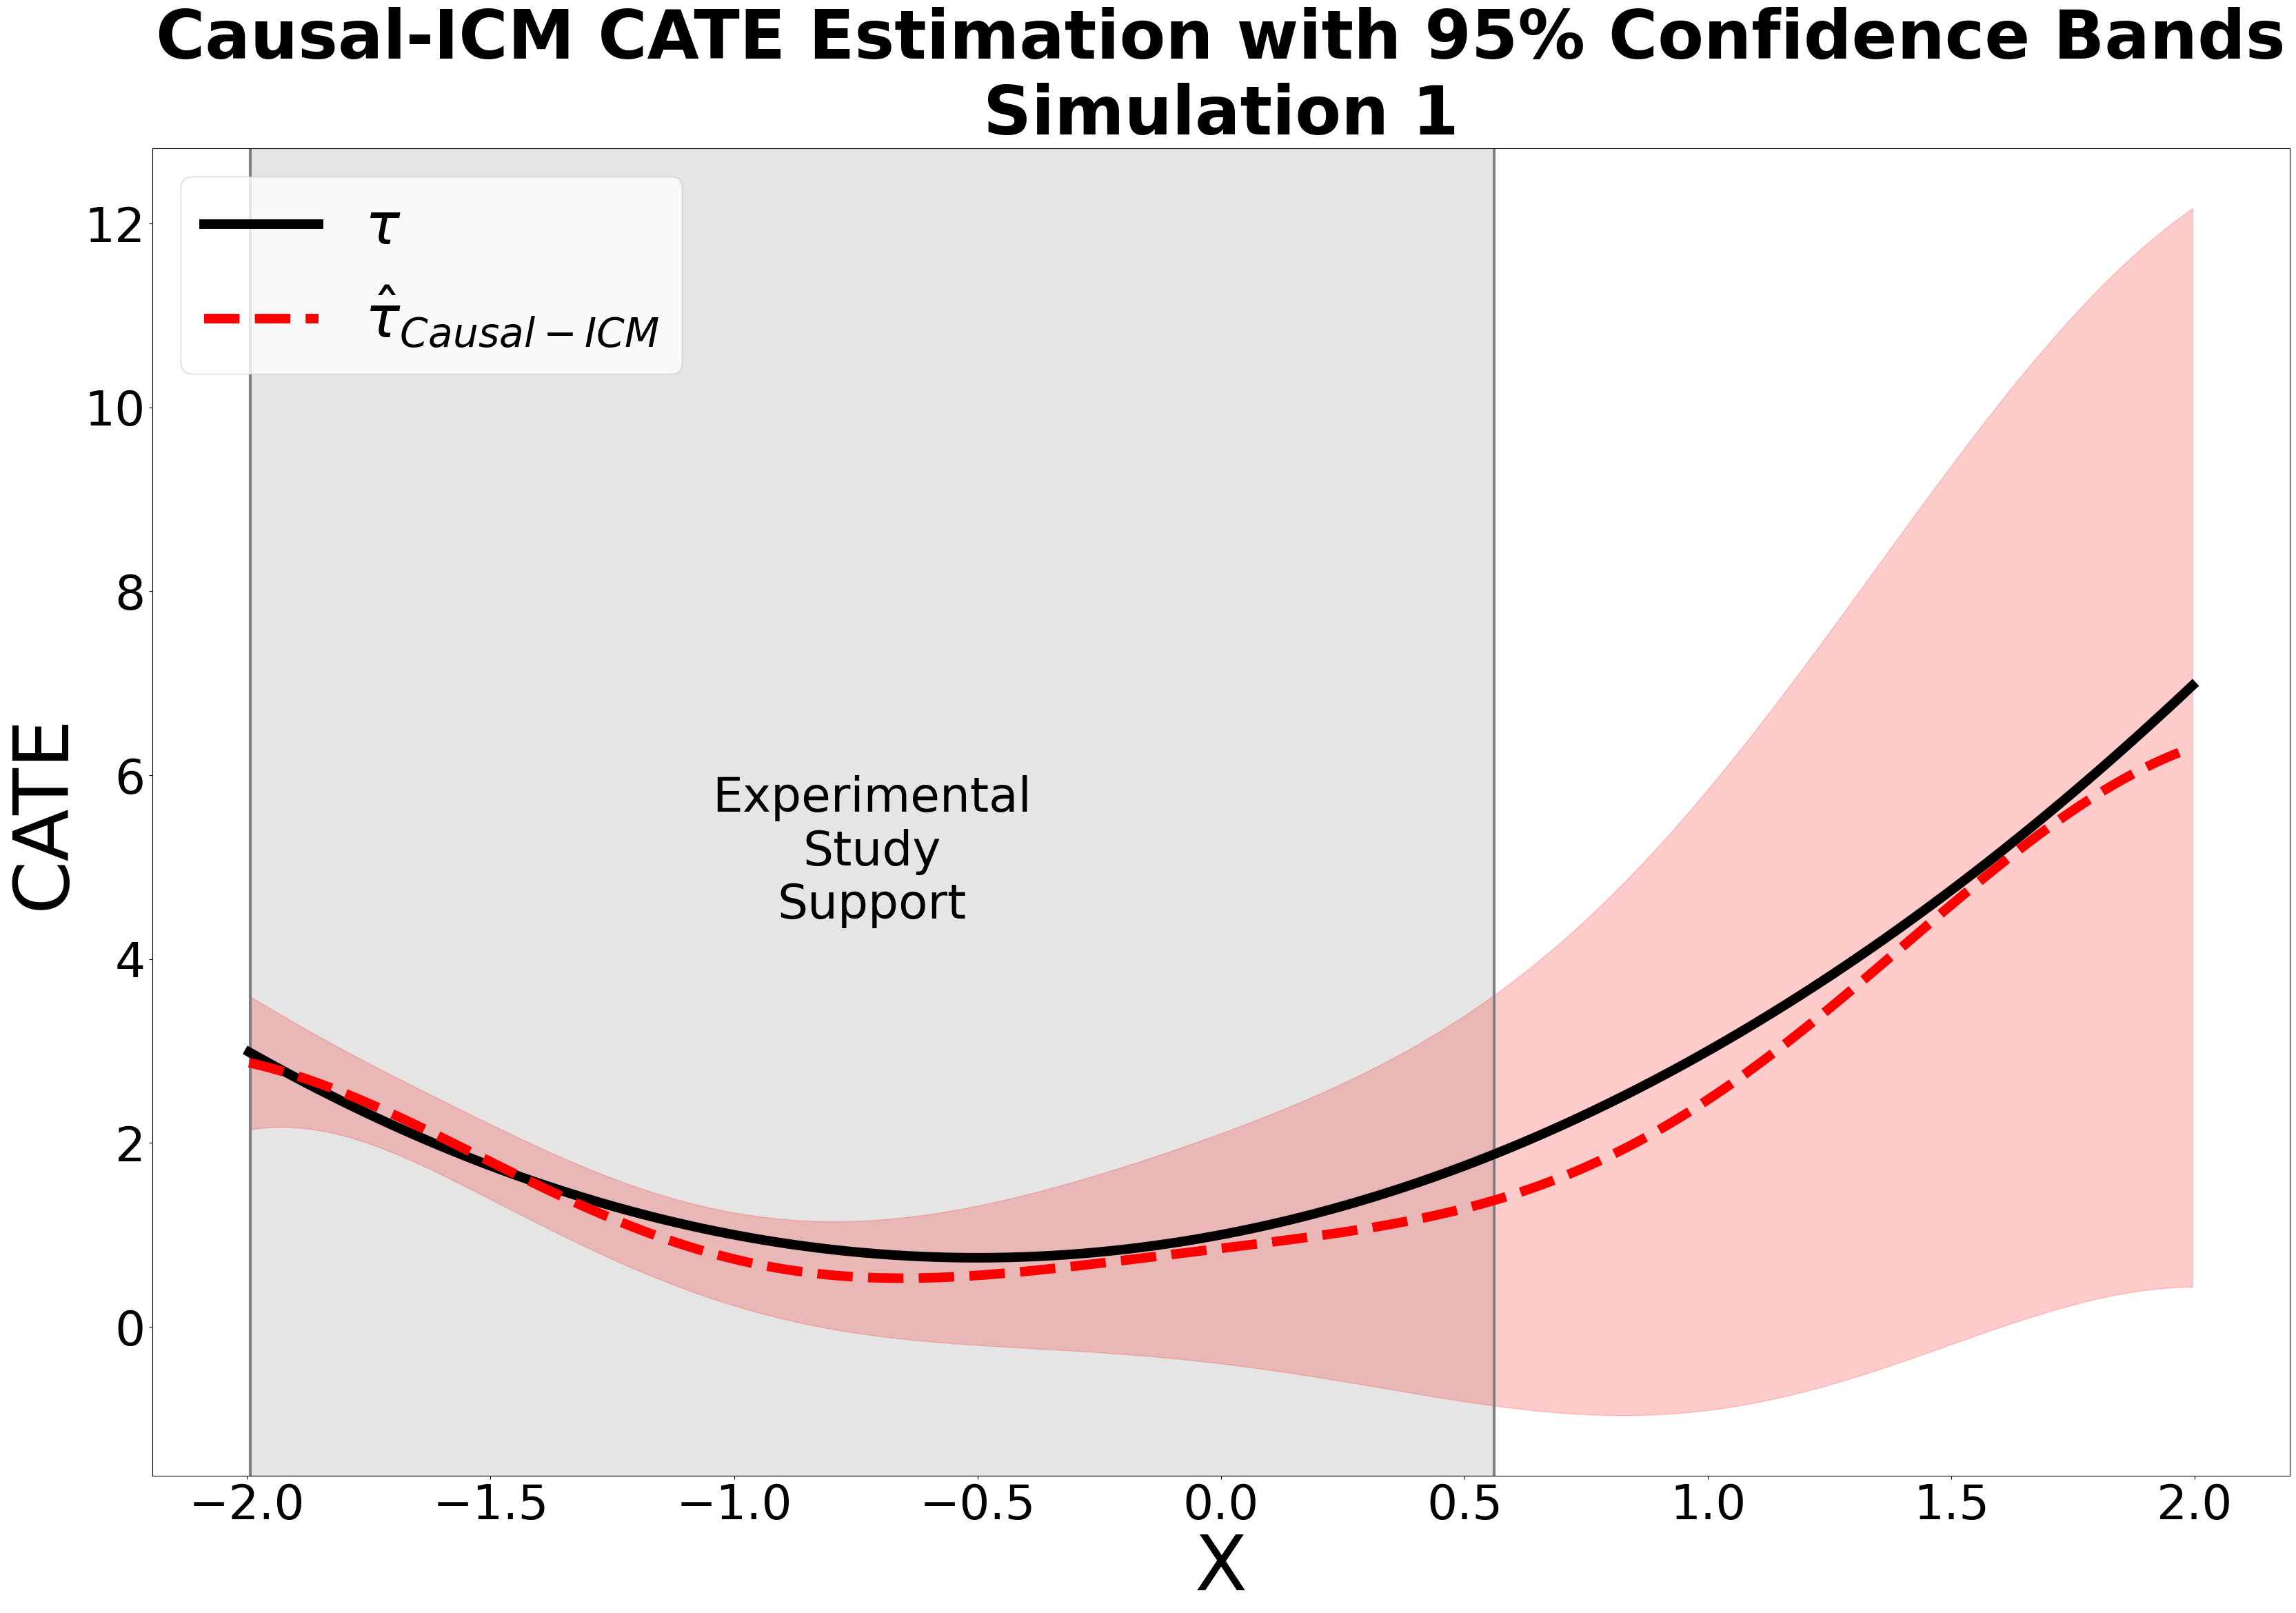

In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from neurIPS.functions.model_training import ICM
from neurIPS.functions.data_simulation import data_simulation8

# ----------------------------
# 1. Fix seeds for reproducibility
# ----------------------------
seed_value = 1234
np.random.seed(seed_value)

# ----------------------------
# 2. Simulate data
# ----------------------------
data_exp, data_obs = data_simulation8(
    1000, beta0=-3.0, beta1=-3.0
)
data_full = np.r_[data_exp, data_obs]

# ----------------------------
# 3. Load best rho
# ----------------------------
best_rho = pd.read_csv(
    "/Users/evangelosdimitriou/myGitRepo/multi-task-GPs-for-Treatment-Effect-Estimation-2/__pycache__/neurIPS/Simulation 8/sim8_best_rho.csv"
).values[0]

# ----------------------------
# 4. Train the ICM model
# ----------------------------
m0, m1 = ICM(
    X_E = data_exp[:,1], X_O = data_obs[:,1],
    T_E = data_exp[:,2], T_O = data_obs[:,2],
    Y_E = data_exp[:,3], Y_O = data_obs[:,3],
    r = 2, ID = 1, AD = 0, rho = best_rho
)

# ----------------------------
# 5. Generate test grid for predictions
# ----------------------------
test_data = np.arange(
    np.min(np.r_[data_exp[:,1], data_obs[:,1]]),
    np.max(np.r_[data_exp[:,1], data_obs[:,1]]),
    0.01
)

# ----------------------------
# 6. Predict potential outcomes
# ----------------------------
predY0_exp = m0.predict_noiseless(np.c_[test_data, np.zeros(len(test_data))])
predY0_obs = m0.predict_noiseless(np.c_[test_data, np.ones(len(test_data))])

predY1_exp = m1.predict_noiseless(np.c_[test_data, np.zeros(len(test_data))])
predY1_obs = m1.predict_noiseless(np.c_[test_data, np.ones(len(test_data))])

# CATE and variance
predCATE_exp = predY1_exp[0] - predY0_exp[0]
varCATE_exp  = predY1_exp[1] + predY0_exp[1]

# True CATE for comparison
true_cate = 1 + test_data + test_data**2

# ----------------------------
# 7. Prepare sorted values for plotting
# ----------------------------
list_CATE_exp = zip(*sorted(zip(test_data, predCATE_exp)))
list_CATE     = zip(*sorted(zip(test_data, true_cate)))

# ----------------------------
# 8. PLOTTING SECTION (WITH EXPLANATORY COMMENTS)
# ----------------------------
plt.figure(figsize=(40,25))

# --- Grey vertical lines marking experimental support boundaries
plt.axvline(x=np.min(data_exp[:,1]), c='grey', linewidth=3.0)
plt.axvline(x=np.max(data_exp[:,1]), c='grey', linewidth=3.0)

# --- Shaded region showing the support of the experimental study
plt.axvspan(
    np.min(data_exp[:,1]),
    np.max(data_exp[:,1]),
    alpha=0.20,
    color='gray'
)

# --- Label inside the shaded region
plt.text(
    (np.max(data_exp[:,1]) + np.min(data_exp[:,1]))/2,
    6,
    'Experimental\nStudy\nSupport',
    verticalalignment='top',
    horizontalalignment='center',
    size=50
)

# --- Plot true CATE curve
plt.plot(*list_CATE, label='$\\tau$', c='black', linewidth=10.0)

# --- Plot estimated CATE from Causal-ICM
plt.plot(*list_CATE_exp, label='$\\hat{\\tau}_{Causal-ICM}$',
         c='red', linewidth=10.0, linestyle='dashed')

# --- Plot confidence band (±2 standard deviations)
plt.fill_between(
    test_data,
    np.hstack(predCATE_exp-2*np.vstack(np.sqrt(varCATE_exp))), 
    np.hstack(predCATE_exp+2*np.vstack(np.sqrt(varCATE_exp))),
    color='red', alpha=0.2
)

# --- Axis formatting
plt.yticks(fontsize=50)
plt.xticks(fontsize=50)

# --- Axis labels
plt.xlabel("X", fontsize=80)
plt.ylabel("CATE", fontsize=80)
plt.title("Causal-ICM CATE Estimation with 95% Confidence Bands\nSimulation 1", fontsize=70, fontweight='bold')

# --- Legend
plt.legend(fontsize=60, loc='upper left')

